In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u
import copy

import pyFLD as fld

In [2]:
# to create a grid, we'll first create 3 1D arrays including ghost cells and pass them to the Grid constructor
# note that a 1-cell array is needed even if you don't intend to solve along that direction. pyFLD will simply
# not solve along directions with only 1 cell, but the internal code structure is always spatially 3D
xi = fld.grid.get_domain_with_ghosts(1, 2, Nx=100) * u.cm
yi = fld.grid.get_domain_with_ghosts(0, 1, Nx=1) * u.cm
zi = fld.grid.get_domain_with_ghosts(0, 1, Nx=1) * u.cm
grid = fld.grid.Grid(xi, yi, zi, geometry='cartesian')

# now we create a fluid object
Gas = fld.fluids.Gas(grid=grid, debug=False, name='basic')

# Next, this object needs a density and temperature. We can use the grid object to compute this.
# Again, these should be 3D arrays. For this problem we'll use constant density.
E0 = 1 * u.erg / u.cm**3
rho = 1 * u.g/u.cm**3 * np.ones(grid.shape)
tmp = fld.tools.Er_to_T(E0) * np.ones(grid.shape)

# Now set them in the Gas object.
Gas.set_density(rho)
Gas.set_temperature(tmp)

# Then, we need to set opacities. We'll set a constant value for both Rosseland and Planck
# via a function call. pyFLD expects the function to receive the fluid object:
Gas.enroll_kappaR(lambda f: 1 * u.cm**2 / u.g)
Gas.enroll_kappaP(lambda f: 1 * u.cm**2 / u.g)

# Finally, call the setup() method to compute everything else internally
Gas.setup()

# to create the context for the radiative problem, we provide the list of fluids (in this case 1).
# For this problem we'll assume a constant flux limiter of 1/3 for simplicity
Box = fld.FLD.RadiativeEnvironment([Gas], verbose=True, name='box', constant_fluxlimiter=True)

# We need to tell the FLD object how to handle boundary conditions for any quantity
# For this we need to set the behavior of each side: x_beg, x_end, y_beg, y_end, z_beg, z_end.
# The currently supported options are zero-gradient ("reflective") or fixed value for E_rad.
# For this problem we'll set a combination of boundaries:
# fixed values in x, with E(x_beg) = E0 and E(x_end) = 2*E0
val, ref = fld.grid.BOUNDARY_FIXEDVALUE, fld.grid.BOUNDARY_REFLECTIVE
bounds = [val, val, ref, ref, ref, ref]
vals   = [E0, 2*E0, 0, 0, 0, 0]
Box.declare_boundaries(bounds, vals)

In [3]:
# Before any solving, let's plot the Box state.
# All fluids include ghost cells, which we probably don't want to plot.
# For this, we can use the slicers "act1/2/3" or "active" to select the active domain
# in 1D quantities in the x1/2/3 directions, or 3D quantities, respectively

x = grid.x1[grid.act1].to_value('cm')
def fmt(qty3D): return 1 * qty3D[grid.active][0,0] # take the 0th (only) element in z and y

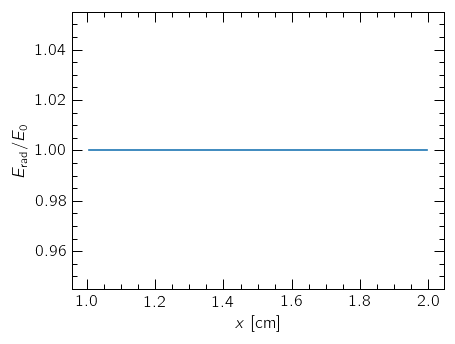

In [4]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=120)

Er_ = fmt(Box.Er).to_value(E0)
img = ax.plot(x, Er_)

ax.set_xlabel(r'$x$ [cm]')
ax.set_ylabel(r'$E_\mathrm{rad} / E_0$')

plt.show()

In [5]:
# now perform some steps with a large enough timestep...
# note that the diffusion coefficient is ~ 1/3 c / (kappa rho) ~ 1e8 cm2/s,
# which for a characteristic length of 1cm implies a diffusion timescale of 1e-8 s.
# However, this is still an implicit solver: stability doesn't mean accuracy.
# For this reason, we give it a few iterations to converge to a steady state.

# try playing with the relative tolerance of the solver and checking the error in the plots!
Box.configure_solver(rtol=1e-10)
for _ in range(5): Box.advance(dt=1e10 * u.s)

# '0' iterations just means that the solver exited partway through the first iteration;
# the solution has still been updated!

RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.
RadiativeEnvironment 'box': Converged in 0 iterations.


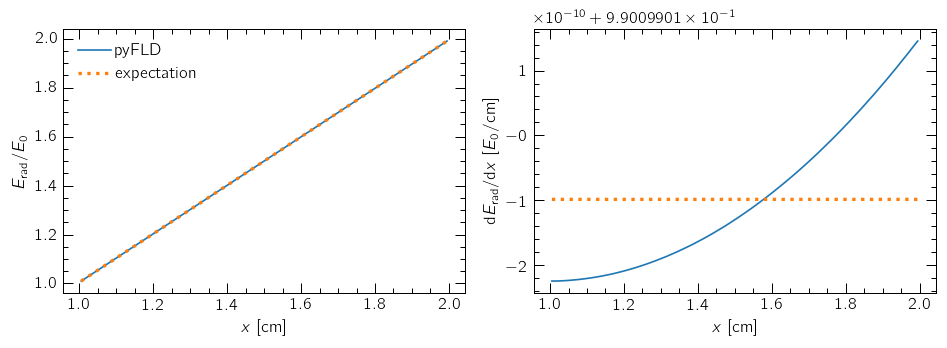

In [6]:
fig, ax = plt.subplots(ncols=2, figsize=(8, 3), dpi=120)

xstart, xend = grid.x1[grid.ibeg-1].to('cm'), grid.x1[grid.iend+1].to('cm')
Estart, Eend = Box.boundary_val[0], Box.boundary_val[1]
Eexp = Estart + (Eend-Estart)/(xend-xstart) * (x*u.cm - xstart)
Eexp = Eexp.to_value(E0)

Er_ = fmt(Box.Er).to_value(E0)
ax[0].plot(x, Er_, label='pyFLD')
ax[0].plot(x, Eexp, label='expectation', ls=':', lw=2)

ax[1].plot(x, np.gradient(Er_, x, edge_order=2), label='pyFLD')
ax[1].plot(x, np.gradient(Eexp, x, edge_order=2), label='expectation', ls=':', lw=2)

ax[0].legend()
for axis in ax: axis.set_xlabel(r'$x$ [cm]')
ax[0].set_ylabel(r'$E_\mathrm{rad} / E_0$')
ax[1].set_ylabel(r'$\mathrm{d}E_\mathrm{rad}/\mathrm{d}x$ [$E_0$/cm]')

fig.tight_layout()
plt.show()

In [7]:
# check whether we've converged to machine precision
np.allclose(Er_, Eexp, rtol=1e-16)

True